## Star classification

https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split #Importar train_test_split and cross validate
from sklearn.linear_model import LogisticRegression #Importar LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix #Importar classification_report y confusion_matrix
from sklearn.pipeline import Pipeline #Importar Pipeline
from sklearn.preprocessing import StandardScaler #Importar StandardScaler
from sklearn.model_selection import GridSearchCV #Importar GridSearchCV

In [129]:
data = pd.read_csv("../datasets\star_classification.csv")

## EDA

In [130]:
data.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [131]:
data = data.drop(columns=["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "fiber_ID"])

In [132]:
data

,alpha,delta,u,g,r,i,z,class,redshift,plate,MJD
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794,5812,56354
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136,10445,58158
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195,4576,55592
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346,9149,58039
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123,6121,56187
...,...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000,9374,57749
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895,7626,56934
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366,2764,54535
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040,6751,56368


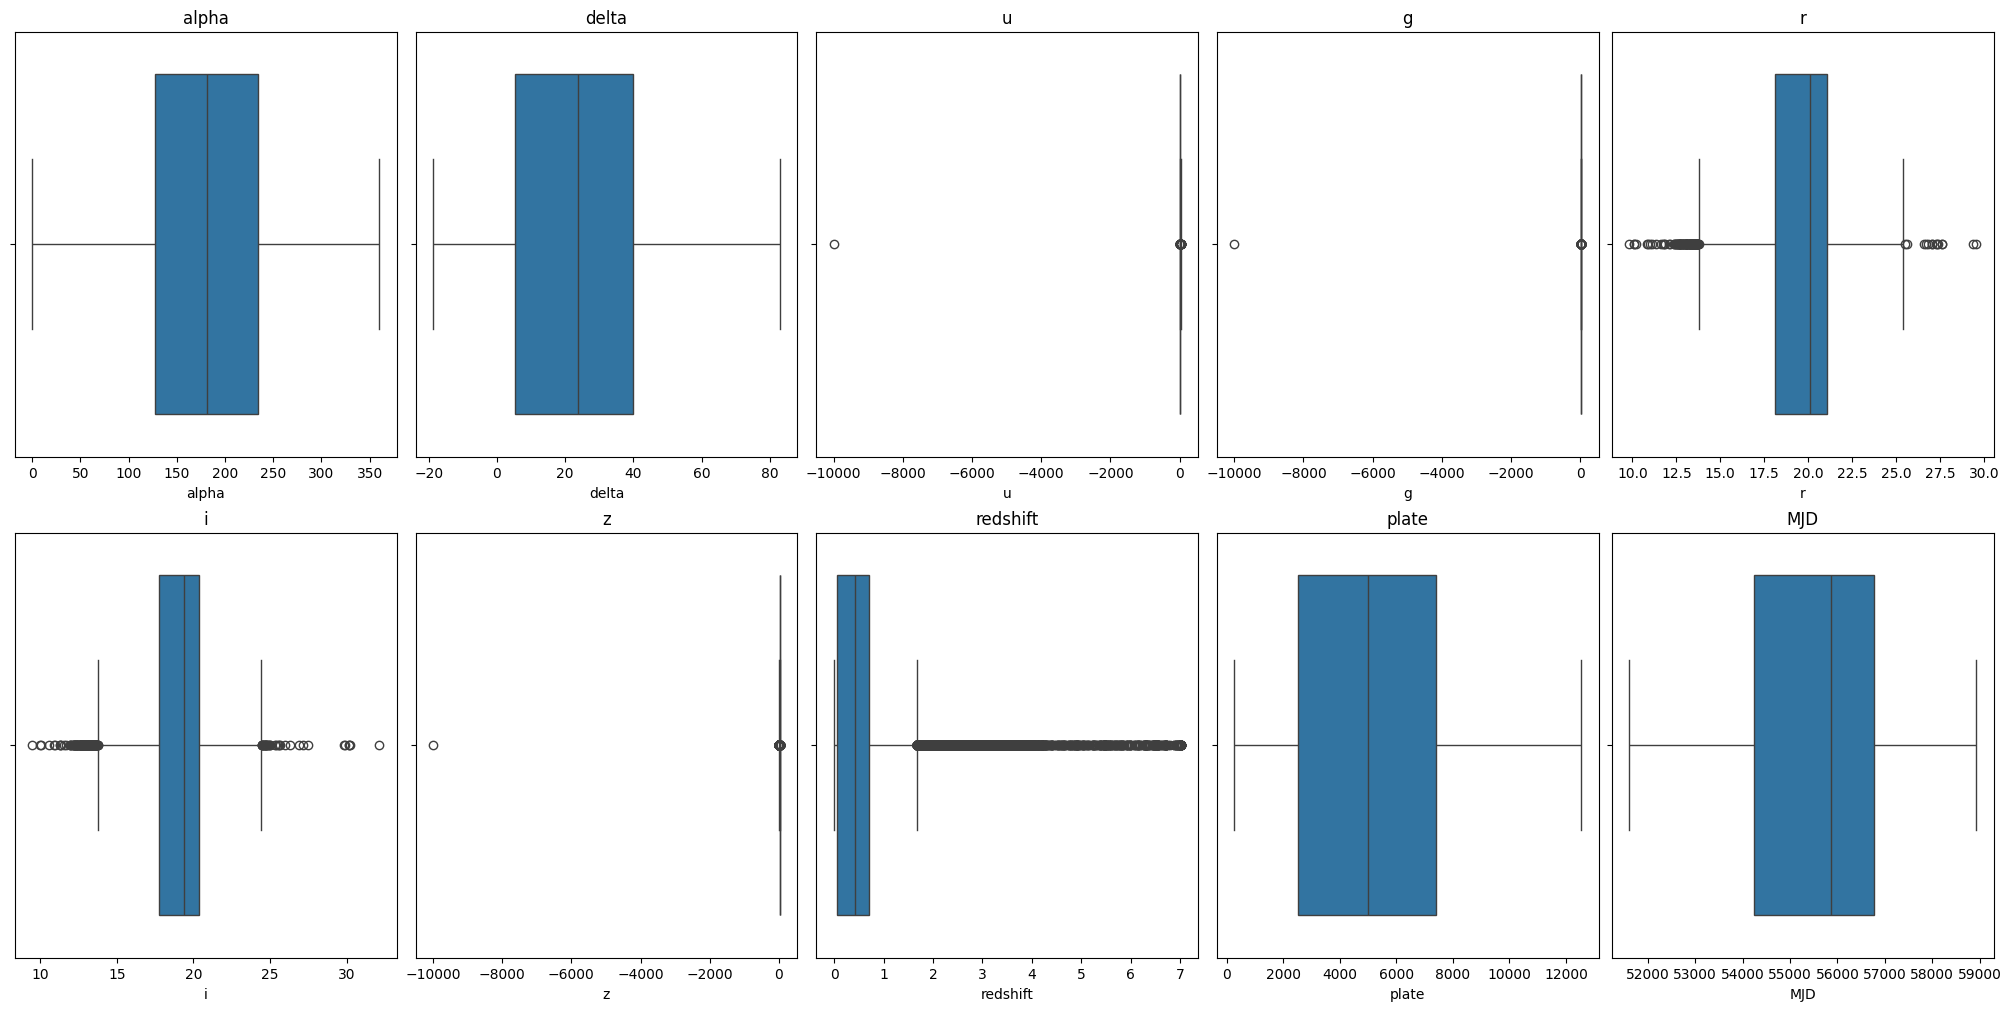

In [133]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10), constrained_layout=True)
for index, column in enumerate(data.drop(columns=["class"]).columns):
    sns.boxplot(data, x = column, ax=axes[index//5, index%5])
    axes[index//5, index%5].set_title(column)
plt.show()

In [134]:
data = data[(data["u"] != -9999) | (data["g"] != -9999) | (data["z"] != -9999)]
data

,alpha,delta,u,g,r,i,z,class,redshift,plate,MJD
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794,5812,56354
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136,10445,58158
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195,4576,55592
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346,9149,58039
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123,6121,56187
...,...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000,9374,57749
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895,7626,56934
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366,2764,54535
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040,6751,56368


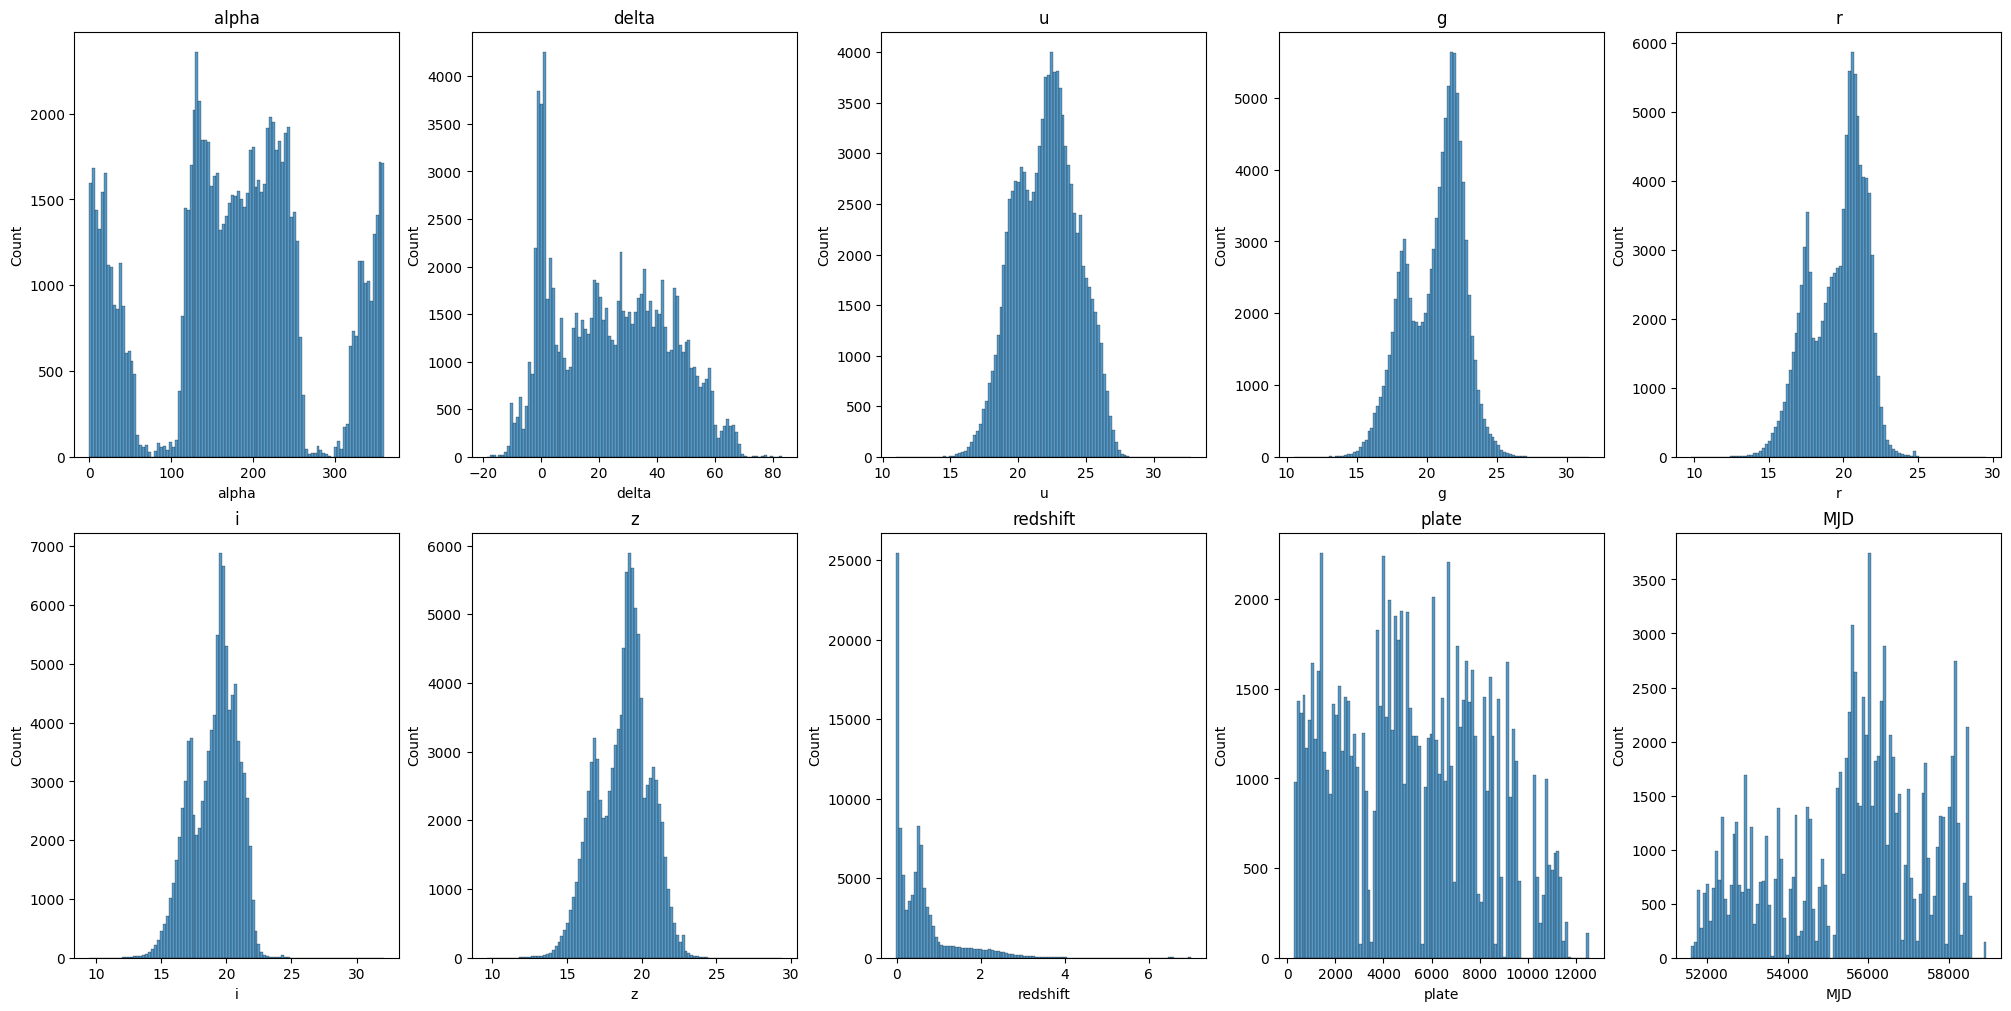

In [135]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10), constrained_layout=True)
for index, column in enumerate(data.drop(columns=["class"]).columns):
    sns.histplot(data, x = column, ax=axes[index//5, index%5], bins=100)
    axes[index//5, index%5].set_title(column)
plt.show()

In [136]:
data = data[["u","g","r","i","z", "class", "redshift"]]
#Selecciono columnas importantes
#data #Display

In [137]:
X = data.drop(columns=["class"]) #X es el conjunto de datos sin la clase
y = data["class"] #y es la clase

<Axes: >

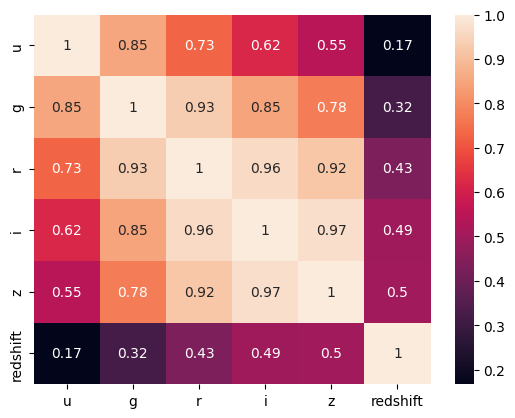

In [138]:
correlation_matrix = X.corr() #Calcula la matriz de correlacion
sns.heatmap(correlation_matrix, annot=True) #Plots heatmap
#Redundancia en las features

## Train model

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #Dividir los datos en train y test

In [141]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
]
)

params = {
        "model__solver": ["saga"],
        "model__l1_ratio": [0, 0.3, 0.5, 0.7, 1],
        "model__max_iter": [100],
        "model__C": [1, 5, 10, 50]
    }

grid_search = GridSearchCV(pipeline, params, cv=5, scoring="roc_auc_ovr", n_jobs=12, verbose = 1)
grid_search.fit(X_train, y_train)
display(grid_search.best_params_)
display(grid_search.best_score_)
pipeline = grid_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Gabriel\anaconda3\envs\ml_course\lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\Gabriel\anaconda3\envs\ml_course\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'model__C': 50,
 'model__l1_ratio': 0,
 'model__max_iter': 200,
 'model__solver': 'saga'}

np.float64(0.988070039408153)

In [142]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__l1_ratio,param_model__max_iter,param_model__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,6.235651,0.099863,0.040349,0.004136,1,0.0,200,saga,"{'model__C': 1, 'model__l1_ratio': 0, 'model__...",0.987544,0.988041,0.986587,0.986086,0.987197,0.987091,0.000690,20
1,6.224082,0.063624,0.043984,0.001839,1,0.3,200,saga,"{'model__C': 1, 'model__l1_ratio': 0.3, 'model...",0.987544,0.988041,0.986587,0.986086,0.987197,0.987091,0.000690,17
2,5.819238,0.360525,0.040848,0.003733,1,0.5,200,saga,"{'model__C': 1, 'model__l1_ratio': 0.5, 'model...",0.987544,0.988041,0.986587,0.986086,0.987197,0.987091,0.000690,19
3,5.607382,0.093983,0.043727,0.003373,1,0.7,200,saga,"{'model__C': 1, 'model__l1_ratio': 0.7, 'model...",0.987544,0.988041,0.986587,0.986086,0.987197,0.987091,0.000690,16
4,5.674775,0.209927,0.046464,0.003293,1,1.0,200,saga,"{'model__C': 1, 'model__l1_ratio': 1, 'model__...",0.987544,0.988041,0.986587,0.986086,0.987197,0.987091,0.000690,18
5,7.880067,0.030950,0.044288,0.002122,5,0.0,200,saga,"{'model__C': 5, 'model__l1_ratio': 0, 'model__...",0.988223,0.988773,0.987228,0.986848,0.987969,0.987808,0.000691,12
6,7.991751,0.036182,0.042033,0.004168,5,0.3,200,saga,"{'model__C': 5, 'model__l1_ratio': 0.3, 'model...",0.988223,0.988772,0.987229,0.986848,0.987969,0.987808,0.000691,13
7,8.035600,0.104288,0.042476,0.002818,5,0.5,200,saga,"{'model__C': 5, 'model__l1_ratio': 0.5, 'model...",0.988223,0.988773,0.987228,0.986848,0.987969,0.987808,0.000691,11
8,8.029101,0.067665,0.042390,0.003419,5,0.7,200,saga,"{'model__C': 5, 'model__l1_ratio': 0.7, 'model...",0.988223,0.988773,0.987228,0.986848,0.987969,0.987808,0.000691,15
9,7.856492,0.310431,0.040861,0.003007,5,1.0,200,saga,"{'model__C': 5, 'model__l1_ratio': 1, 'model__...",0.988223,0.988773,0.987228,0.986848,0.987969,0.987808,0.000691,14


In [143]:
y_pred = pipeline.predict(X_train) #Predecir los datos de test
print(classification_report(y_train, y_pred)) #Mostrar el reporte de clasificacion

              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97     47567
         QSO       0.94      0.88      0.91     15194
        STAR       0.96      1.00      0.98     17238

    accuracy                           0.96     79999
   macro avg       0.96      0.95      0.95     79999
weighted avg       0.96      0.96      0.96     79999



In [144]:
y_pred = pipeline.predict(X_test) #Valores totalmente nuevos
y_prob = pipeline.predict_proba(X_test) #Predict probability
print(classification_report(y_test, y_pred)) #Report

              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97     11878
         QSO       0.95      0.89      0.92      3767
        STAR       0.96      1.00      0.98      4355

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



In [145]:
pipeline.named_steps["model"].classes_.tolist()

['GALAXY', 'QSO', 'STAR']

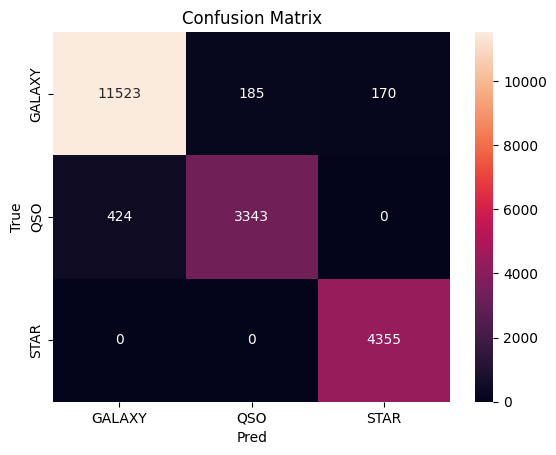

In [146]:
labels = pipeline.named_steps["model"].classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)
ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=labels, yticklabels=labels)
ax.set_xlabel("Pred")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.show()

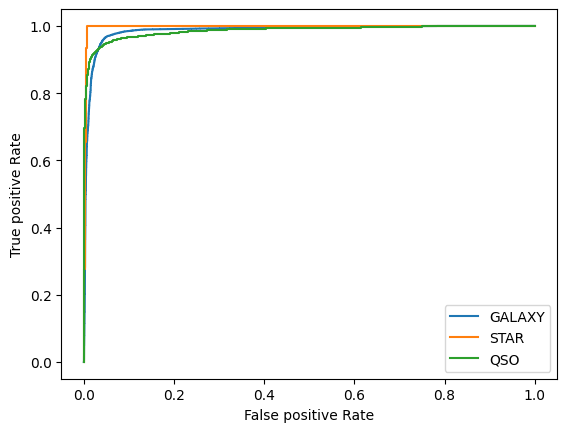

In [147]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test == "GALAXY", y_prob[:,0]) #Selecciono las galaxias y la primera columna
plt.plot(fpr, tpr, label ="GALAXY")

fpr, tpr, thresholds = roc_curve(y_test == "STAR", y_prob[:,2]) #Selcciono las estrellas y la 3ra columna
plt.plot(fpr, tpr, label ="STAR")

fpr, tpr, thresholds = roc_curve(y_test == "QSO", y_prob[:,1]) #Selecciono qso y la 2da columna
plt.plot(fpr, tpr, label ="QSO")
plt.legend()
plt.xlabel("False positive Rate")
plt.ylabel("True positive Rate")
plt.show()